In [1]:
import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw_data
from src.config import TARGET_COLUMN

In [2]:
df = load_raw_data()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df[TARGET_COLUMN].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
df[TARGET_COLUMN].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


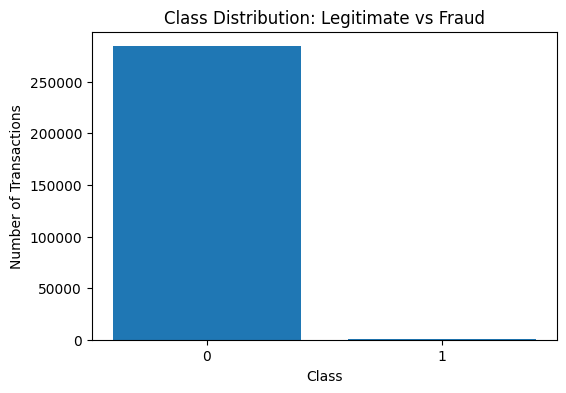

In [9]:
class_counts = df[TARGET_COLUMN].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution: Legitimate vs Fraud")
plt.show()

In [10]:
fraud_rate = df[TARGET_COLUMN].mean() * 100
print(f"Fraud rate: {fraud_rate:.4f}%")

Fraud rate: 0.1727%


# Phase 1: Exploratory Data Analysisdasd

The dataset contains 284,807 credit card transactions and 31 columns. The target variable is 'Class', where 0 represents a legitimate transaction and 1 represents a fraudulent transaction.

The dataset is highly imbalanced, with only 492 fraudulent transactions, or approximately 0.17% of the data. Because of this imbalance, accuracy alone is not a reliable evaluation metric. A model could predict every transaction as legitimate and still achieve approximately 99.83% accuracy while failing to detect every fraudulent transaction.

For this reason, the project will focus on precision, recall, F1-score, ROC-AUC, confusion matrix analysis, and threshold tuning.

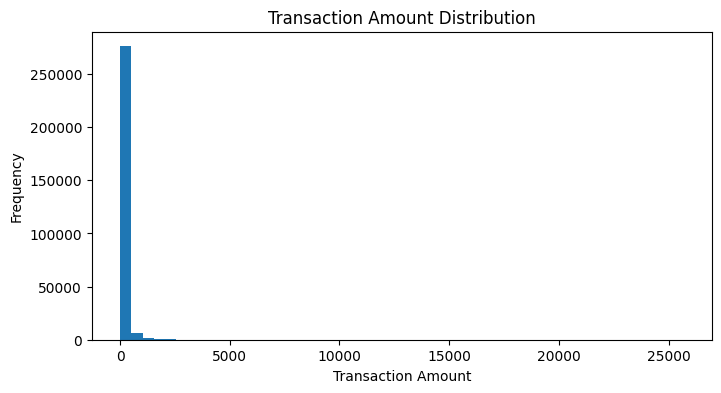

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(df["Amount"], bins=50)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.show()

In [12]:
df.groupby(TARGET_COLUMN)["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


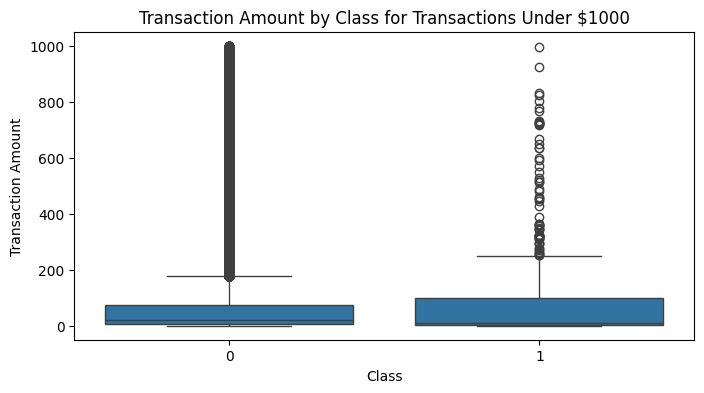

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[df["Amount"] < 1000], x=TARGET_COLUMN, y="Amount")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount by Class for Transactions Under $1000")
plt.show()

## Amount Analysis

The 'Amount' column is one of the few directly interpretable features in the dataset. Most transactions are relatively small, but the dataset contains some very large transaction amounts, making the distribution right-skewed.

I compared transaction amounts across legitimate and fraudulent transactions to check whether fraudulent transactions tend to occur at different amount ranges. Because the dataset contains outliers, I also visualized transactions under $1000 to make the class-level comparison easier to interpret.

In [15]:
amount_bins = [0, 10, 50, 100, 500, 1000, df["Amount"].max()]
amount_labels = ["$0-10", "$10-50", "$50-100", "$100-500", "$500-1000", "$1000+"]

df["Amount_Bucket"] = pd.cut(
    df["Amount"],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True
)

bucket_summary = df.groupby("Amount_Bucket", observed=True).agg(
    total_transactions=("Class", "count"),
    fraud_transactions=("Class", "sum"),
    fraud_rate=("Class", "mean")
)

bucket_summary["fraud_rate_percent"] = bucket_summary["fraud_rate"] * 100

bucket_summary

,total_transactions,fraud_transactions,fraud_rate,fraud_rate_percent
Amount_Bucket,,,,
$0-10,100264,249,0.002483,0.248344
$10-50,90781,57,0.000628,0.062788
$50-100,37254,56,0.001503,0.150319
$100-500,47366,95,0.002006,0.200566
$500-1000,6202,26,0.004192,0.419220
$1000+,2940,9,0.003061,0.306122


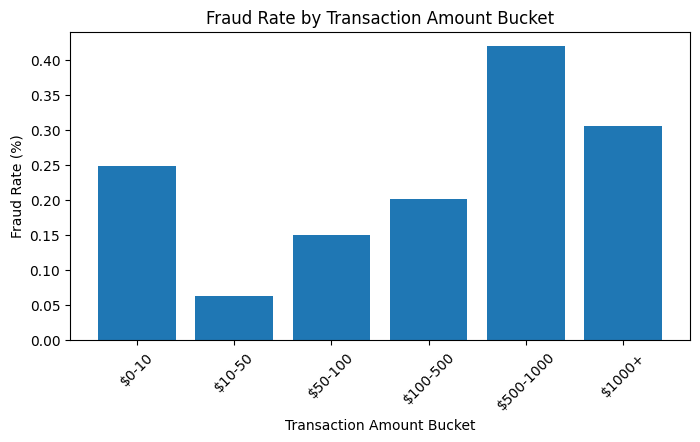

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(bucket_summary.index.astype(str), bucket_summary["fraud_rate_percent"])
plt.xlabel("Transaction Amount Bucket")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Amount Bucket")
plt.xticks(rotation=45)
plt.show()

## Fraud Rate by Transaction Amount Bucket

I grouped transactions into amount buckets to compare fraud rates across different transaction ranges. The $500–1000 bucket had the highest fraud rate at approximately 0.42%, followed by the $1000+ bucket at approximately 0.31%.

However, the $0–10 bucket contained the largest number of fraud cases by count, with 249 fraudulent transactions. This shows that fraud risk is not only concentrated in high-value transactions. Smaller transactions may contain many fraud cases because they occur more frequently.

This is important from a business perspective because fraud detection systems need to consider both fraud rate and fraud volume. High-dollar transactions may deserve stricter review thresholds, while low-dollar transactions may still require monitoring due to their large transaction volume.

In [21]:
v_features = [col for col in df.columns if col.startswith("V")]

means_by_class = df.groupby(TARGET_COLUMN)[v_features].mean().T
std_by_feature = df[v_features].std()

means_by_class["difference"] = means_by_class[1] - means_by_class[0]
means_by_class["standardized_difference"] = means_by_class["difference"] / std_by_feature
means_by_class["absolute_standardized_difference"] = means_by_class["standardized_difference"].abs()

means_by_class.sort_values("absolute_standardized_difference", ascending=False).head(10)

Class,0,1,difference,standardized_difference,absolute_standardized_difference
V17,0.011535,-6.665836,-6.677371,-7.861863,7.861863
V14,0.012064,-6.971723,-6.983787,-7.285436,7.285436
V12,0.010832,-6.259393,-6.270225,-6.275236,6.275236
V10,0.009824,-5.676883,-5.686707,-5.222673,5.222673
V16,0.007164,-4.139946,-4.147110,-4.732777,4.732777
V3,0.012171,-7.033281,-7.045452,-4.646614,4.646614
V7,0.009637,-5.568731,-5.578368,-4.509253,4.509253
V11,-0.006576,3.800173,3.806749,3.729500,3.729500
V4,-0.007860,4.542029,4.549889,3.213497,3.213497
V18,0.003887,-2.246308,-2.250195,-2.684633,2.684633


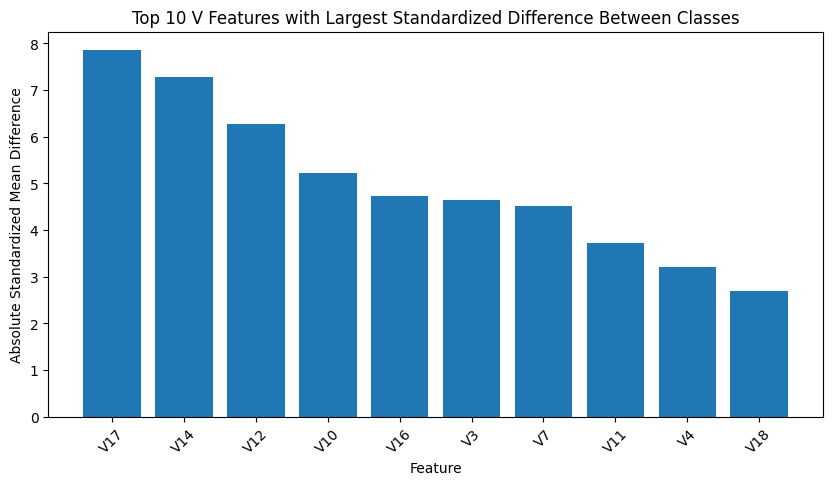

In [22]:
top_std_diff_features = (
    means_by_class
    .sort_values("absolute_standardized_difference", ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(10, 5))
plt.bar(
    top_std_diff_features,
    means_by_class.loc[top_std_diff_features, "absolute_standardized_difference"]
)
plt.xlabel("Feature")
plt.ylabel("Absolute Standardized Mean Difference")
plt.title("Top 10 V Features with Largest Standardized Difference Between Classes")
plt.xticks(rotation=45)
plt.show()

## Standardized Feature Difference Analysis

I compared the anonymized 'V1'–`V28' features across legitimate and fraudulent transactions using standardized mean differences. This is more reliable than raw mean differences because it accounts for the scale and spread of each feature.

The largest standardized differences appeared in 'V17', 'V14', 'V12', 'V10', 'V16', 'V3', and 'V7`. Since these features show strong separation between fraud and legitimate transactions, they may be useful predictors for the classification model.

Because the `V' features are anonymized, I cannot assign direct business meanings to them. However, the statistical differences suggest that the transformed transaction patterns captured by these variables are relevant for fraud detection.

# Phase 1 Summary

The dataset contains 284,807 transactions and 31 columns. The target variable is 'Class`, where 0 represents a legitimate transaction and 1 represents fraud.

The dataset is highly imbalanced: only 492 transactions are fraudulent, which is approximately 0.17% of the dataset. Because of this, accuracy is not a reliable metric for this project. A model could classify every transaction as legitimate and still achieve approximately 99.83% accuracy while detecting no fraud.

The 'Amount` feature is strongly right-skewed, with most transactions being relatively small and a few very large outliers. Fraudulent transactions had a higher mean amount than legitimate transactions, but a lower median, showing that fraud is not limited to high-value transactions.

When grouping transactions into amount buckets, the $500–1000 bucket had the highest fraud rate, while the $0–10 bucket contained the largest number of fraud cases by volume. This suggests that both fraud rate and fraud volume matter for business decision-making.

Among the anonymized 'V1'–'V28' features, 'V17', 'V14', 'V12', 'V10', 'V16', 'V3', and 'V7` showed the largest standardized differences between legitimate and fraudulent transactions. These features may provide strong predictive signal for the fraud detection model.

Based on this EDA, the next step is to build a baseline classification model and evaluate it using precision, recall, F1-score, ROC-AUC, confusion matrix analysis, and threshold tuning instead of accuracy alone.